In [1]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# abs_phenotypes = True
abs_phenotypes = False
extreme_pheno_dir = 'Bottom'

# Load annotation configuration
if abs_phenotypes:
    config_path = "/home/dnanexus/ukbgym/config_odds.yaml" # If abs_pheno then deleteriousness direction
else:    
    config_path = "/home/dnanexus/ukbgym/config_olink_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",-1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",-1
"""missense""","""score_pai3d""","""#feb72d""","""PrimateAI-3D""",-1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",1
…,…,…,…,…
"""regulatory""","""fz_blood""","""crimson""","""Flashzoi Blood""",1
"""regulatory""","""abexp_min""","""#80CBC4""","""AbExp min""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",-1


In [3]:
new_anno_df_path = '/home/dnanexus/data_dir/flashzoi_proximal_variants_gencode40_avg_score.parquet'

new_anno_df = (
    pl.read_parquet(new_anno_df_path)
    .with_columns(
        fz_blood = (pl.col('RNA:blood_7531') + pl.col('RNA:blood_7532') + pl.col('RNA:blood_7533'))/3
    )
    .with_columns(
        max_fz_blood = pl.col('fz_blood').abs()
    )
    .select(['id', 'region', 'fz_blood', 'max_fz_blood'])
    .lazy()
)

new_anno_df.head().collect()

id,region,fz_blood,max_fz_blood
str,str,f32,f32
"""chr1:3652123:G:A""","""ENSG00000078900""",0.077435,0.077435
"""chr1:3652442:G:T""","""ENSG00000078900""",-0.05002,0.05002
"""chr1:3652966:G:T""","""ENSG00000078900""",0.001191,0.001191
"""chr1:3652415:C:G""","""ENSG00000078900""",0.430102,0.430102
"""chr1:3652543:C:G""","""ENSG00000078900""",0.029333,0.029333


In [4]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

min_range = -500
max_range = +500

# Join new annotation if specified above
if new_anno_df_path is not None:
    anno = (
        anno
        .join(
            new_anno_df,
            on=['id', 'region'],
            how='left'
        )
    )

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno_wide = (
    anno
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # filter_expression &

        # Proximity to TSS
        (pl.col('dist_to_tss') >= min_range) &
        (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
    # .filter(pl.col('gene_name').is_in(['LDLR', 'APOB']))
)

anno_wide

am_pathogenicity,esmscoremissense,score_pai3d,abexp_min,delta_score,gene_name,abexp_abs_max,strand,loftee_hc,gpn_star_llr_calibrated_mean,cadd_raw,absplice2_max,fz_blood,gene_length,promoterai,max_fz_blood,region,tss,pangolin_score,promoterai_abs,id,dist_to_tss,absplice_dna_max,gpn_score
f32,f32,f32,f32,f32,str,f32,str,i8,f32,f32,f32,f32,i64,f32,f32,str,i64,f32,f32,str,i64,f32,f32
0.0,0.0,0.0,-0.005749,0.0,"""LY75""",0.005749,"""-1""",0,2.414017,0.214129,0.000034,-0.01811,101403,-0.1316,0.01811,"""ENSG00000054219""",159904756,0.01,0.1316,"""chr2:159904473:A:T""",283,0.001,1.52
0.0,0.0,0.0,-0.006261,0.0,"""GGT1""",0.006261,"""1""",0,-2.606816,0.367113,0.0,0.009185,34196,-0.023,0.009185,"""ENSG00000100031""",24594810,0.0,0.023,"""chr22:24594671:C:G""",-139,0.0,-3.65
0.0,0.0,0.0,0.002221,0.0,"""IL17RA""",0.002851,"""1""",0,-0.438371,0.519545,0.0,0.001317,30741,0.0486,0.001317,"""ENSG00000177663""",17084953,0.0,0.0486,"""chr22:17084628:C:G""",-325,0.0,-0.98
0.0,0.0,0.0,0.002469,0.0,"""IL17RA""",0.0031,"""1""",0,0.252168,0.108395,0.0,-0.009782,30741,-0.0095,0.009782,"""ENSG00000177663""",17084953,0.0,0.0095,"""chr22:17084790:G:C""",-163,0.0,-0.78
0.1282,-5.309,0.377387,-0.00961,0.0,"""IL17RA""",0.00961,"""1""",0,-0.060007,-0.752414,0.000033,0.028211,30741,-0.0202,0.028211,"""ENSG00000177663""",17084953,0.0,0.0202,"""chr22:17085102:C:A""",149,0.001,-1.63
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0.0,-0.039129,0.0,"""EP300""",0.039129,"""1""",0,-3.786235,1.935566,0.000033,-0.006158,87487,-0.0741,0.006158,"""ENSG00000100393""",41092591,0.0,0.0741,"""chr22:41092883:C:T""",292,0.001,-4.05
0.0,0.0,0.0,0.001765,0.0,"""TNFSF11""",0.002291,"""1""",0,-0.830258,0.956175,0.0,0.017454,45279,0.0974,0.017454,"""ENSG00000120659""",42562735,0.0,0.0974,"""chr13:42562312:T:G""",-423,0.0,-2.59
0.0,0.0,0.0,0.000079,0.0,"""ARHGAP18""",0.000526,"""-1""",0,1.007943,1.085525,0.0,0.00982,134047,-0.1305,0.00982,"""ENSG00000146376""",129710177,0.0,0.1305,"""chr6:129710261:G:A""",-84,0.0,-0.56


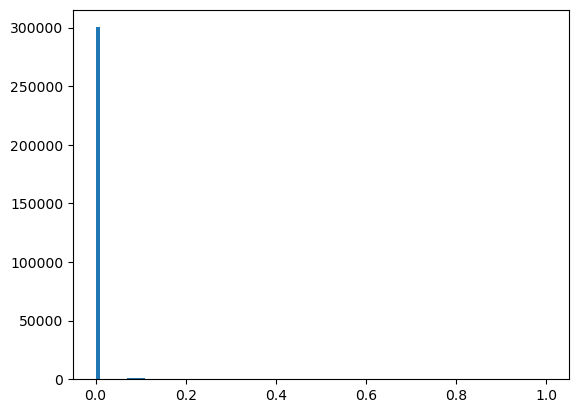

In [5]:
plt.hist(anno_wide['am_pathogenicity'].drop_nulls(), bins=100)
plt.show()

In [6]:
selected_annos = anno_config_df.filter(
    # (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation', 'splicing'])) # CDS
    # pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation']) # missense
    # pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']) # 'splicing'

    (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir', 'regulatory'])) # non coding
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])) # introns
)['annotation'].to_list()

melted_anno = (
    anno_wide

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )

    .filter(
        # Remove null annotation scores
        (pl.col('annotation_score').is_not_null())
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="average", descending=True).over(["region", "annotation"]).cast(pl.Float32),
    )

    .drop(['annotation_score_dircor'])
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr2:159904473:A:T""","""ENSG00000054219""","""cadd_raw""",0.214129,"""genetic_diversity""",-1,86.0
"""chr22:24594671:C:G""","""ENSG00000100031""","""cadd_raw""",0.367113,"""genetic_diversity""",-1,168.0
"""chr22:17084628:C:G""","""ENSG00000177663""","""cadd_raw""",0.519545,"""genetic_diversity""",-1,292.0
"""chr22:17084790:G:C""","""ENSG00000177663""","""cadd_raw""",0.108395,"""genetic_diversity""",-1,74.0
"""chr22:17085102:C:A""","""ENSG00000177663""","""cadd_raw""",-0.752414,"""genetic_diversity""",-1,2.0
…,…,…,…,…,…,…
"""chr22:41092883:C:T""","""ENSG00000100393""","""abexp_abs_max""",0.039129,"""regulatory_nondir""",-1,475.5
"""chr13:42562312:T:G""","""ENSG00000120659""","""abexp_abs_max""",0.002291,"""regulatory_nondir""",-1,298.5
"""chr6:129710261:G:A""","""ENSG00000146376""","""abexp_abs_max""",0.000526,"""regulatory_nondir""",-1,13.0


## Odds ratio computation

In [20]:
n_steps = 101
min_rank_cutoff = 10
max_rank_cutoff = 10_000
max_rank_cutoff = np.min([max_rank_cutoff, anno_wide.shape[0]])
or_threshold_pheno = 0.9

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})

cutoffs_lazy.collect()

rank_cutoff
i64
10
10
11
12
13
…
7585
8128
8709


In [21]:
# Read Olink RVAT significant
olnk_subset = pl.read_csv('/home/dnanexus/data_dir/olink/olink_genebass1e6_371genes.tsv', separator='\t')
olnk_rvat_genes = (
    pl.read_csv('/home/dnanexus/data_dir/olink/olink_rvat_fdr.tsv', separator='\t')
    .filter(pl.col('is_plof_significant_fdr')==True)
    .filter(pl.col('n_pos')>=10)
    .filter(pl.col('gene').is_in(olnk_subset['region']))['gene'].to_list()
)
olnk_rvat_genes = [g+'_olink' for g in olnk_rvat_genes]


# Read Olink phenotype data
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

# Merge phenotype data and annotation data
gp_corr_df = (
    olink_appv
    .filter(
        (pl.col('phenotype').is_in(olnk_rvat_genes)) &
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(pl.col('mean_pheno_value'))
    )
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('phenotype')
    )
    .with_columns(
        mean_pheno_value_rank=pl.col('mean_pheno_value')
            .rank(method="average")
            .cast(pl.Float32)
    )
    .with_columns(
        mean_pheno_value_ptile=(
            pl.col('mean_pheno_value_rank') / pl.len()
        ).cast(pl.Float32)
    )
    .with_columns(
        mean_pheno_value_ptile = pl.when(extreme_pheno_dir.lower() == 'bottom')
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
    .rename({
        'phenotype': 'olink_prot',
    })
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_corr_df
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "olink_prot", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff', descending=True)

or_df

/tmp/ipykernel_383316/3879832487.py:7: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


Executing with odds ratios...


annotation,region,olink_prot,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,i64,u64,u64,u64,u64,f64
"""max_fz_blood""","""ENSG00000130559""","""ENSG00000130559_olink""",10000,13,137,0,0,NaN
"""fz_blood""","""ENSG00000204381""","""ENSG00000204381_olink""",10000,11,60,0,0,NaN
"""gpn_score""","""ENSG00000015475""","""ENSG00000015475_olink""",10000,7,78,0,0,NaN
"""cadd_raw""","""ENSG00000104320""","""ENSG00000104320_olink""",10000,3,54,0,0,NaN
"""gpn_star_llr_calibrated_mean""","""ENSG00000107159""","""ENSG00000107159_olink""",10000,12,62,0,0,NaN
…,…,…,…,…,…,…,…,…
"""cadd_raw""","""ENSG00000184922""","""ENSG00000184922_olink""",10,0,4,20,134,0.0
"""abexp_abs_max""","""ENSG00000159640""","""ENSG00000159640_olink""",10,0,0,20,204,NaN
"""promoterai_abs""","""ENSG00000109062""","""ENSG00000109062_olink""",10,0,4,26,146,0.0


## Plotting

In [ ]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = np.log10(pl.col('rank_cutoff')),
        log_rank_cutoff_inv = np.log10(1/pl.col('rank_cutoff')),
    )
    .with_columns(
        # log_rank_cutoff_inv = (np.log10(min_rank_cutoff) + np.log10(max_rank_cutoff)) - pl.col('log_rank_cutoff'),
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'log_rank_cutoff', 'rank_cutoff', 'log_rank_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .sort('log_rank_cutoff')
    
    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('n_gene_phenos') >= 10) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 100


annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""abexp_abs_max""",1.0,10,-1.0,51,0.0,0.575512,0.229758,1.025838,0.125185,"""#80CBC4""","""AbExp abs max""","""regulatory_nondir"""
"""abexp_min""",1.0,10,-1.0,41,0.0,1.105351,0.442162,1.971988,0.238714,"""#80CBC4""","""AbExp min""","""regulatory"""
"""gpn_score""",1.0,10,-1.0,121,0.0,0.601856,0.193007,0.98015,0.223562,"""#942c80""","""GPN-MSA""","""conservation"""
"""fz_blood""",1.0,10,-1.0,118,0.0,1.118707,0.300751,1.708178,0.529236,"""crimson""","""Flashzoi Blood""","""regulatory"""
"""gpn_star_llr_calibrated_mean""",1.0,10,-1.0,115,0.0,0.844322,0.248366,1.331119,0.357526,"""#942c80""","""GPN-Star""","""conservation"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""abexp_abs_max""",2.769377,588,-2.769377,11,0.592105,0.758798,0.19332,1.137706,0.37989,"""#80CBC4""","""AbExp abs max""","""regulatory_nondir"""
"""cadd_raw""",2.769377,588,-2.769377,14,0.45591,0.741571,0.190986,1.115904,0.367239,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""max_fz_blood""",2.769377,588,-2.769377,12,0.680371,0.730828,0.12036,0.966735,0.494922,"""pink""","""Flashzoi abs max across blood""","""regulatory_nondir"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


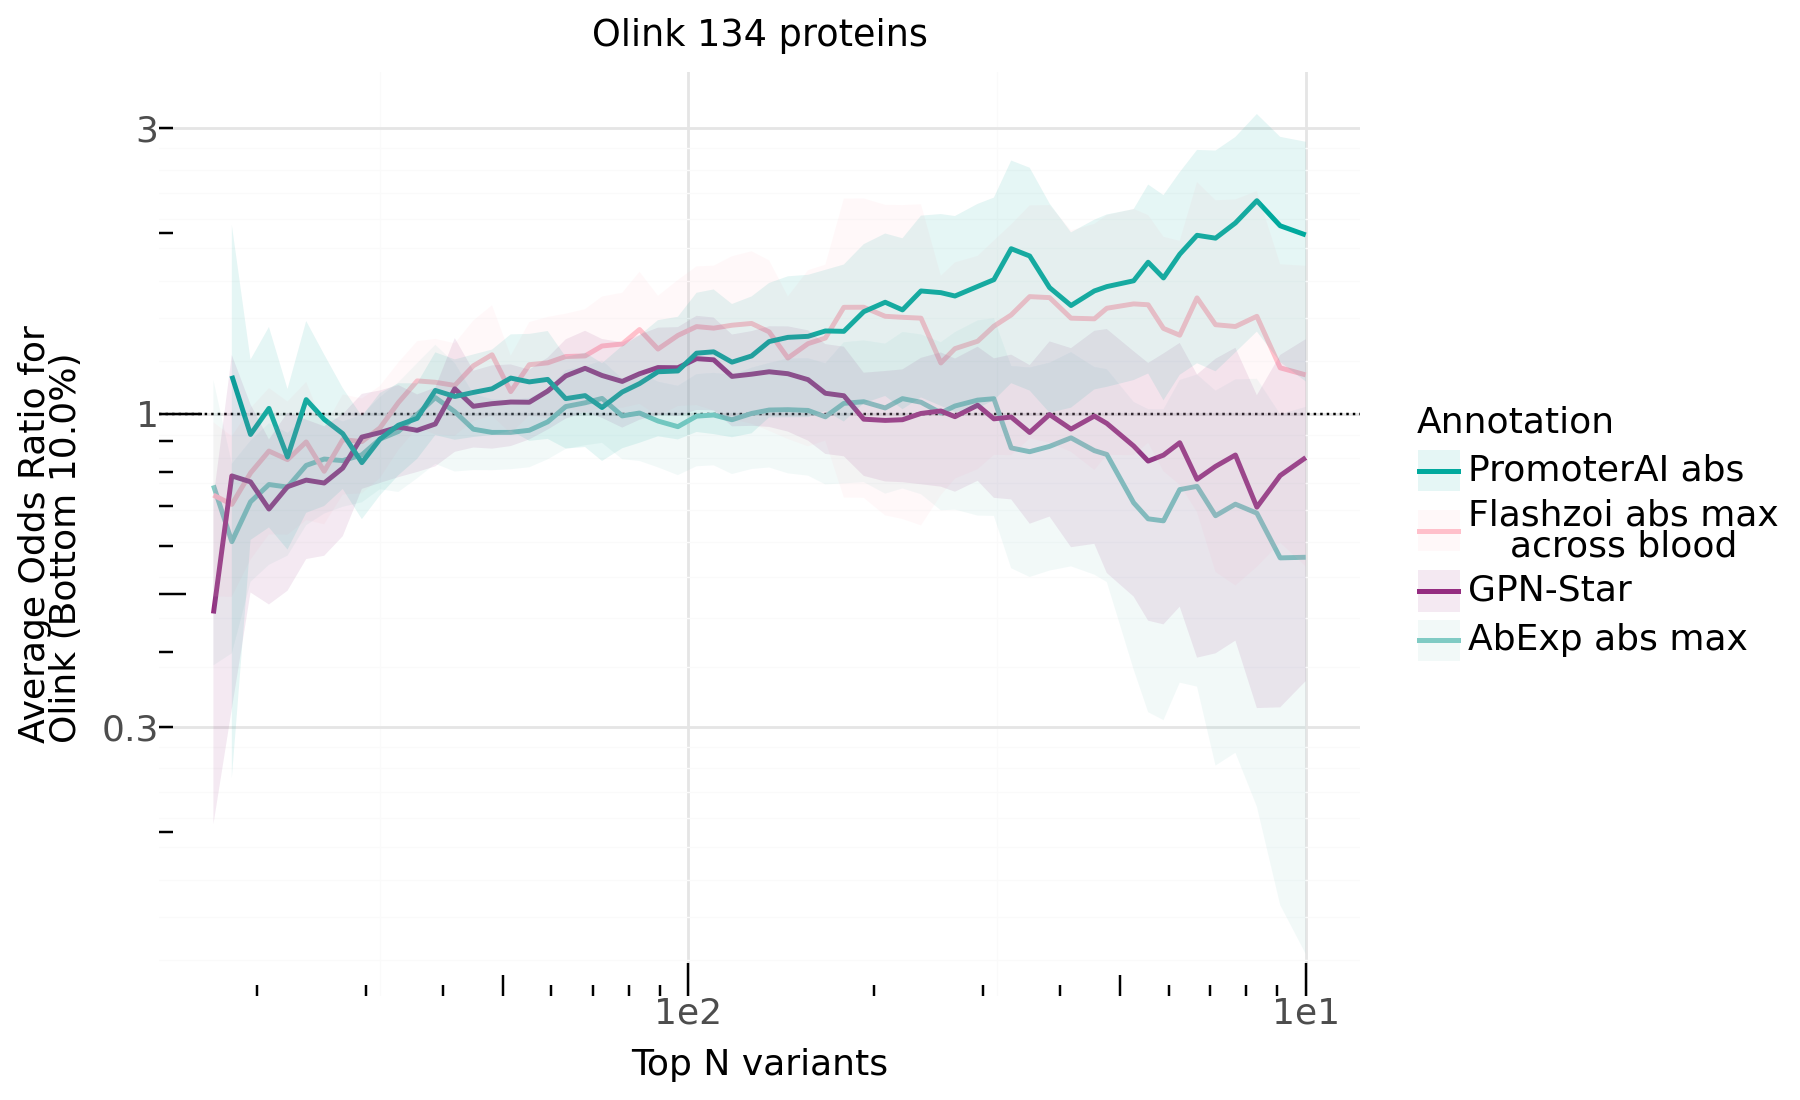

In [36]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') <= -3.5) &
        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'delta_score']))
        (pl.col('annotation').is_in(['gpn_star_llr_calibrated_mean', 'abexp_abs_max', 'promoterai_abs', 'max_fz_blood']))
        # (pl.col('category').is_in(['missense', 'genetic_diversity']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

# Determine legend order based on final average odds ratio
legend_order = (
    plot_df.sort("log_rank_cutoff_inv")
    .group_by("label", maintain_order=True)
    .last()
    .sort("avg_odds_ratio", descending=True)
    ['label']
    .to_list()
)

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict, limits=legend_order)
    + scale_color_manual(values=color_dict, limits=legend_order)
    + labs(
        title=f"Olink {plt_df['n_gene_phenos'].max()} proteins",
        y=f"Average Odds Ratio for\nOlink ({extreme_pheno_dir} {pheno_label}%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    # + lims(y=(-0.1, 3.5))
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(9, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [24]:
plt_df.head()

annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""abexp_min""",1.0,10,-1.0,41,0.0,1.105351,0.442162,1.971988,0.238714,"""#80CBC4""","""AbExp min""","""regulatory"""
"""gpn_score""",1.0,10,-1.0,121,0.0,0.601856,0.193007,0.98015,0.223562,"""#942c80""","""GPN-MSA""","""conservation"""
"""fz_blood""",1.0,10,-1.0,118,0.0,1.118707,0.300751,1.708178,0.529236,"""crimson""","""Flashzoi Blood""","""regulatory"""
"""cadd_raw""",1.0,10,-1.0,122,0.0,0.890886,0.318662,1.515464,0.266308,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""promoterai""",1.0,10,-1.0,104,0.0,0.710057,0.233902,1.168504,0.251609,"""#00A99D""","""PromoterAI""","""regulatory"""
